<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/Aberrations/WaveFRontMismatchSeidel_descriptive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

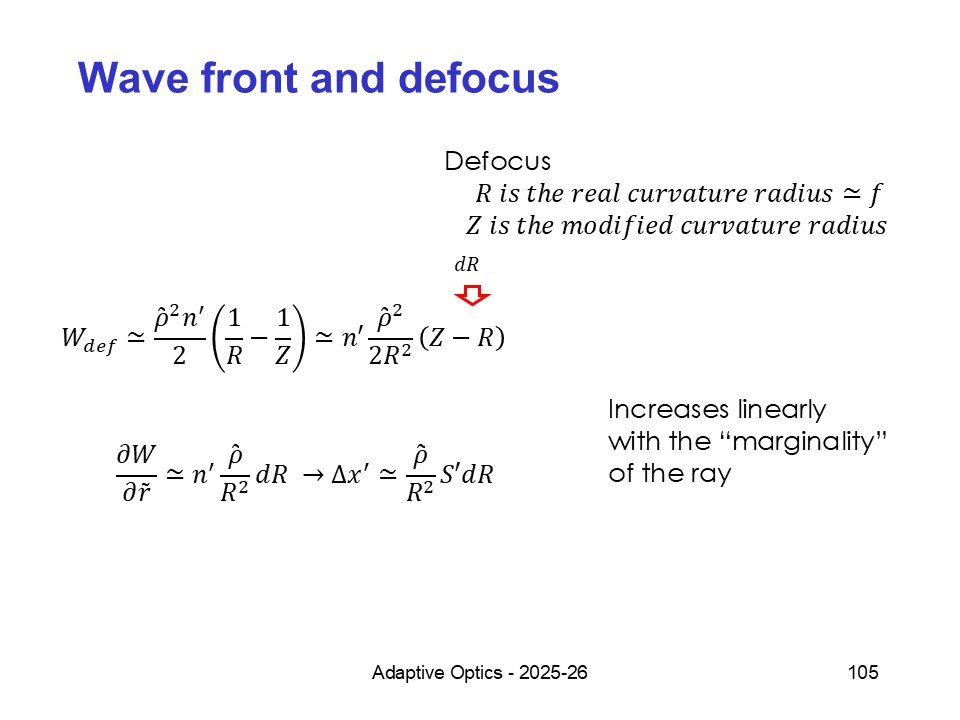

focal length[mm] =  22.0 ; curvature radius= 66.0 [mm]


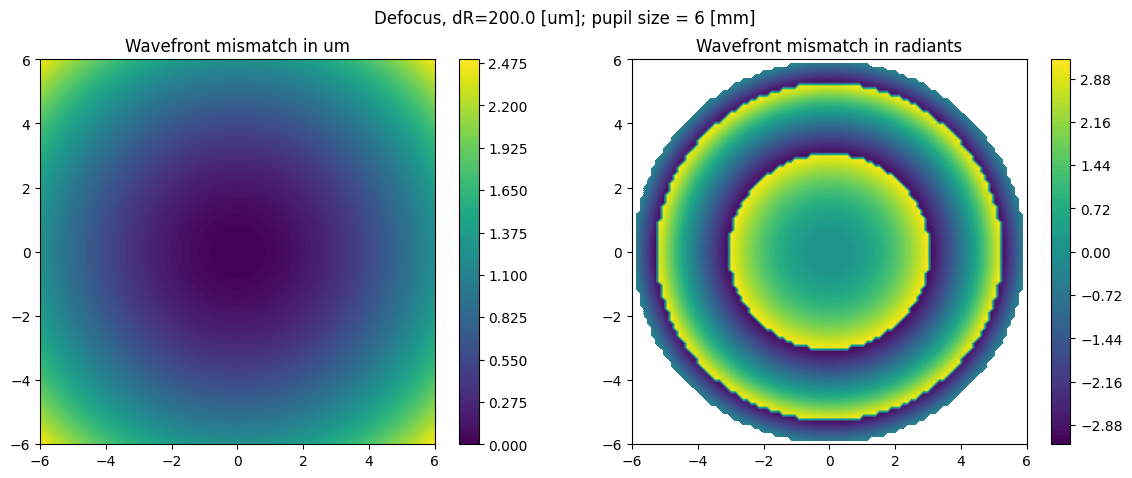

In [2]:

'''
computation of the defocus aberrations
All units in mm
'''
import matplotlib.pyplot as plt
import numpy as np

###### input parameters ALL UNITS in mm
pupil_radius = 6 ### mm
RI           = 1.5 ### refractive index

####definition of the coordinates in the pupil plane. x is the xtilde of the slides.
x     = np.linspace(-pupil_radius,pupil_radius,100)
xx,yy = np.meshgrid(x,x)
rho2  = xx**2 + yy**2   ### this is the square of the polar distance

DioptricPower   = 1/22 ## in mm^-1
focal           = 1/DioptricPower
CurvRadius      = 2*RI/DioptricPower
print ('focal length[mm] = ',focal,'; curvature radius=',CurvRadius,'[mm]')

####### this is a circular mask to avoid to show the wave front over a rectangle
####### then over a circular pupil

mask = rho2 < pupil_radius**2
maschera = np.zeros_like(xx)
maschera[mask] = 1
maschera[~mask] = 0
########################################
deltaR = 0.2 # mm  is the delta in the curcature radius, meaning Z- R

#### now compute the wave front mismATCH FOR DEFOCUS
W   = RI * rho2 *deltaR / 2. / CurvRadius**2

wav = 0.6325e-3 ### in mm
k0  = 2*np.pi/0.6325E-3  ## 1/mm , define the wave vector

 #### npow plot it
F,A = plt.subplots(1,2,figsize=(14,5))
I0  = A[0].contourf(xx,yy,W*1000,100) ##multiply by 1000 toget in um
plt.colorbar(I0,ax=A[0])
A[0].set_title('Wavefront mismatch in um')
Ww  = ((W*k0* maschera + np.pi) % (2*np.pi) - np.pi)

Ww_masked = np.ma.array(Ww, mask=(maschera==0))

I1  = A[1].contourf(xx,yy,Ww_masked,100)
plt.colorbar(I1,ax=A[1])
A[1].set_title('Wavefront mismatch in radiants')
F.suptitle('Defocus, dR='+str(np.round(deltaR*1000,1))+' [um]; pupil size = '+str(pupil_radius)+' [mm]')
plt.show()

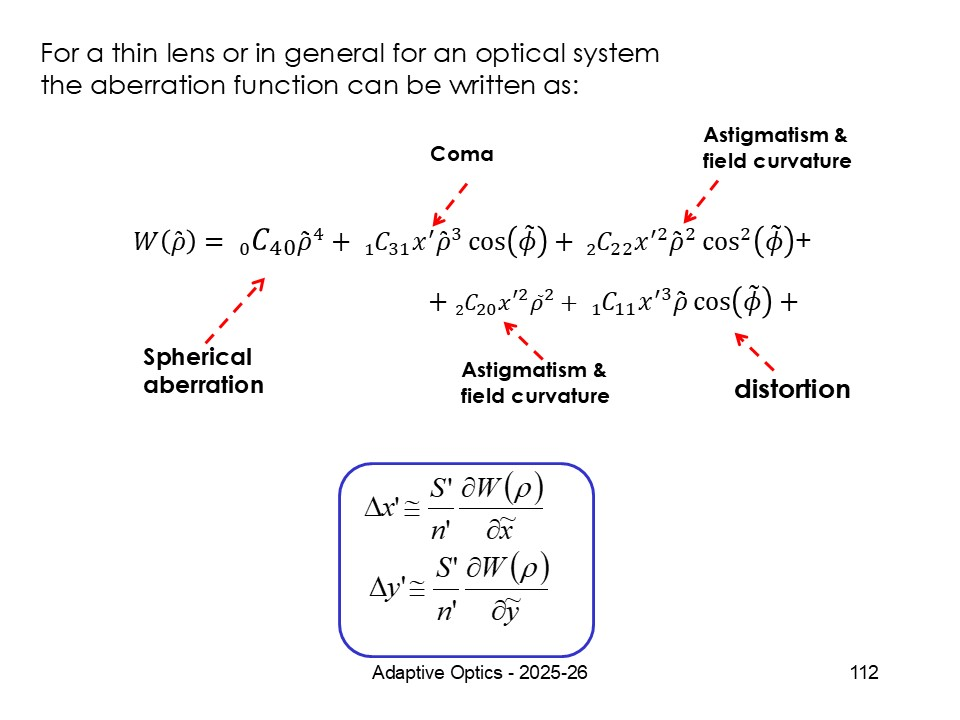

focal length[mm] =  22.0 ; curvature radius= 66.0 [mm]


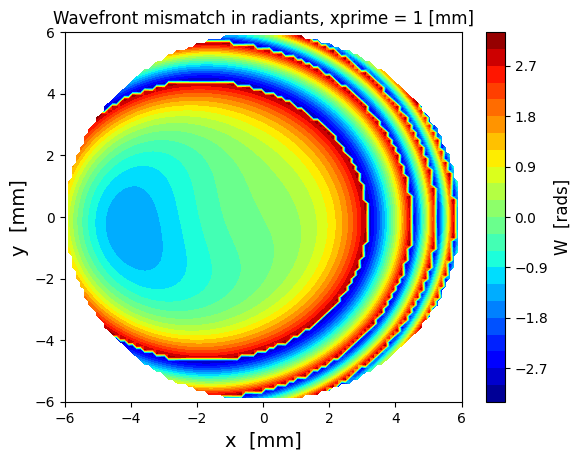

In [4]:
###    general description of the wave front mismatch
####   Seidel equations
#####  general case described by genierc coefficients
#####  it is based on the previous slide


import matplotlib.pyplot as plt
import numpy as np

#### paramters
pupil_radius = 6 ### mm
wav = 0.6325e-3 ### in mm
k0  = 2*np.pi/0.6325E-3  ## 1/mm
RI = 1.5

### circular pupil mask
mask = rho2 < pupil_radius**2
maschera = np.zeros_like(xx)
maschera[mask] = 1
maschera[~mask] = 0

#### definition of the pupil coordinates, Cartesian and polar (radial)
x     = np.linspace(-pupil_radius,pupil_radius,100)
xx,yy = np.meshgrid(x,x)
rho2  = xx**2 + yy**2
DioptricPower = 1/22 ## in mm^-1
focal = 1/DioptricPower
xprime = +1 ##mm off axis coordinate, this is an important parameter of the off-axis aberrations

CurvRadius = 2*RI/DioptricPower
print ('focal length[mm] = ',focal,'; curvature radius=',CurvRadius,'[mm]')

### these are the Seidel coefficients, that are reported in the previous slide.
####  YOU NEED TO CHANGTE THE PARAMETERS HERE
C040 = 0.1e-5
C131 = 0.5e-5
C222 = 1e-5
C220 = 1e-5
C311 = 0e-5

W040 = C040 * rho2**2
W131 = C131 * xprime * rho2*xx
W222 = (C222+C220)*xprime**2*xx+C220*xprime**2*yy
W311 = C311 * xprime**3 * xx

Wtot = W040 + W131+W222+W311
Ww  = ((Wtot*k0* maschera + np.pi) % (2*np.pi) - np.pi)
Ww_masked = np.ma.array(Ww, mask=(maschera==0))

plt.figure()
im = plt.contourf(xx,yy,Ww_masked,20,cmap='jet')
plt.xlabel('x  [mm]',fontsize=14)
plt.ylabel('y  [mm]',fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label("W  [rads]", fontsize=12)
plt.title('Wavefront mismatch in radiants, xprime = '+str(xprime)+' [mm]')
plt.show()
